In [1]:
import os
import time
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [2]:
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)

print("Random seed:", SEED)

Random seed: 42


In [3]:
selected_features = [
    "dur",
    "proto",
    "service",
    "spkts",
    "dpkts",
    "sbytes",
    "dbytes",
    "rate",
    "sttl",
    "dttl",
    "sload",
    "dload",
    "sinpkt",
    "dinpkt",
    "sjit",
    "djit",
    "tcprtt",
    "synack",
    "ackdat",
    "ct_srv_src",
    "ct_state_ttl",
    "ct_dst_ltm",
    "ct_src_ltm",
    "ct_srv_dst"
]

len(selected_features)

24

In [4]:
UNSW_TRAIN_PATH = r"C:\AMRITA\Final_Year_Project_zero_day_27\model_selection_zeroday_fyp_27\UNSW_NB15_training-set.csv"

train_df = pd.read_csv(UNSW_TRAIN_PATH)

print("Training shape:", train_df.shape)
train_df.head()

Training shape: (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [5]:
missing_features = [
    f for f in selected_features
    if f not in train_df.columns
]

print("Missing features:", missing_features)

assert len(missing_features) == 0, \
    f"Missing features: {missing_features}"

Missing features: []


In [6]:
X_train_df = train_df[selected_features].copy()

print("Feature matrix:", X_train_df.shape)

Feature matrix: (82332, 24)


In [7]:
proto_encoder = LabelEncoder()
service_encoder = LabelEncoder()

X_train_df["proto"] = proto_encoder.fit_transform(
    X_train_df["proto"].astype(str)
)

X_train_df["service"] = service_encoder.fit_transform(
    X_train_df["service"].astype(str)
)

print("Protocol classes:")
print(proto_encoder.classes_)

print("\nService classes:")
print(service_encoder.classes_)

Protocol classes:
['3pc' 'a/n' 'aes-sp3-d' 'any' 'argus' 'aris' 'arp' 'ax.25' 'bbn-rcc'
 'bna' 'br-sat-mon' 'cbt' 'cftp' 'chaos' 'compaq-peer' 'cphb' 'cpnx'
 'crtp' 'crudp' 'dcn' 'ddp' 'ddx' 'dgp' 'egp' 'eigrp' 'emcon' 'encap'
 'etherip' 'fc' 'fire' 'ggp' 'gmtp' 'gre' 'hmp' 'i-nlsp' 'iatp' 'ib'
 'idpr' 'idpr-cmtp' 'idrp' 'ifmp' 'igmp' 'igp' 'il' 'ip' 'ipcomp' 'ipcv'
 'ipip' 'iplt' 'ipnip' 'ippc' 'ipv6' 'ipv6-frag' 'ipv6-no' 'ipv6-opts'
 'ipv6-route' 'ipx-n-ip' 'irtp' 'isis' 'iso-ip' 'iso-tp4' 'kryptolan'
 'l2tp' 'larp' 'leaf-1' 'leaf-2' 'merit-inp' 'mfe-nsp' 'mhrp' 'micp'
 'mobile' 'mtp' 'mux' 'narp' 'netblt' 'nsfnet-igp' 'nvp' 'ospf' 'pgm'
 'pim' 'pipe' 'pnni' 'pri-enc' 'prm' 'ptp' 'pup' 'pvp' 'qnx' 'rdp' 'rsvp'
 'rvd' 'sat-expak' 'sat-mon' 'sccopmce' 'scps' 'sctp' 'sdrp' 'secure-vmtp'
 'sep' 'skip' 'sm' 'smp' 'snp' 'sprite-rpc' 'sps' 'srp' 'st2' 'stp'
 'sun-nd' 'swipe' 'tcf' 'tcp' 'tlsp' 'tp++' 'trunk-1' 'trunk-2' 'ttp'
 'udp' 'unas' 'uti' 'vines' 'visa' 'vmtp' 'vrrp' 'wb-expak' 'wb-

In [8]:
X_train_df.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

train_medians = X_train_df.median()

X_train_df = X_train_df.fillna(train_medians)

print("Remaining NaN:", X_train_df.isna().sum().sum())

Remaining NaN: 0


In [29]:
X_train_df.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

train_medians = X_train_df.median()

X_train_df = X_train_df.fillna(
    train_medians
)

scaler = StandardScaler()
X_train_df = pd.DataFrame(
    scaler.fit_transform(X_train_df),
    columns=selected_features,
    index=X_train_df.index
)

print("Remaining NaN:", X_train_df.isna().sum().sum())
print("Scaled training matrix:", X_train_df.shape)

Remaining NaN: 0
Scaled training matrix: (82332, 24)


In [30]:
input_dim = X_train_df.shape[1]
latent_dim = 2

inputs = Input(shape=(input_dim,))

x = Dense(32, activation="relu")(inputs)
x = Dense(16, activation="relu")(x)

latent = Dense(
    latent_dim,
    activation="linear",
    name="latent"
)(x)

x = Dense(16, activation="relu")(latent)
x = Dense(32, activation="relu")(x)

outputs = Dense(
    input_dim,
    activation="linear"
)(x)

autoencoder = Model(inputs, outputs)

encoder = Model(
    inputs,
    latent
)

autoencoder.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 2)              │            34 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,746 (10.73 KB)

 Trainable params: 2,746 (10.73 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

start_time = time.time()

ae_history = autoencoder.fit(
    X_train_df,
    X_train_df,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

ae_time = time.time() - start_time

print(f"AE training time: {ae_time:.2f} seconds")

Epoch 1/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.6299 - val_loss: 0.6515
Epoch 2/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3873 - val_loss: 0.5288
Epoch 3/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2858 - val_loss: 0.4774
Epoch 4/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2059 - val_loss: 0.4133
Epoch 5/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1710 - val_loss: 0.3783
Epoch 6/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1558 - val_loss: 0.3650
Epoch 7/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1470 - val_loss: 0.3532
Epoch 8/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1398 - val_loss: 0.3416
Epoch 9/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1339 - val_loss: 0.3308
Epoch 10/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1290 - val_loss: 0.3236
Epoch 11/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1242 - val_loss: 0.3160
Epoch 12/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

In [32]:
latent_train = encoder.predict(
    X_train_df,
    batch_size=256,
    verbose=0
)

print("Latent shape:", latent_train.shape)

Latent shape: (82332, 2)


In [15]:
class ClusteringLayer(Layer):

    def __init__(
        self,
        n_clusters,
        weights=None,
        alpha=1.0,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.n_clusters = n_clusters
        self.alpha = alpha

        if weights is not None:
            self.initial_weights = weights
        else:
            self.initial_weights = None

    def build(self, input_shape):

        input_dim = int(input_shape[1])

        self.clusters = self.add_weight(
            shape=(self.n_clusters, input_dim),
            initializer="glorot_uniform",
            name="cluster_centers"
        )

        if self.initial_weights is not None:
            self.set_weights(self.initial_weights)
            self.initial_weights = None

        super().build(input_shape)

    def call(self, inputs):

        q = 1.0 / (
            1.0 +
            (
                tf.reduce_sum(
                    tf.square(
                        tf.expand_dims(inputs, axis=1)
                        - self.clusters
                    ),
                    axis=2
                )
                / self.alpha
            )
        )

        q = tf.pow(
            q,
            (self.alpha + 1.0) / 2.0
        )

        q = tf.transpose(
            tf.transpose(q) / tf.reduce_sum(
                q,
                axis=1
            )
        )

        return q

In [16]:
def target_distribution(q):

    weight = (
        q ** 2
    ) / (
        np.sum(q, axis=0) + 1e-10
    )

    return (
        np.transpose(
            np.transpose(weight) /
            (
                np.sum(
                    weight,
                    axis=1
                ) + 1e-10
            )
        )
    )

In [33]:
n_clusters = 5

clustering_layer = ClusteringLayer(
    n_clusters=n_clusters,
    name="clustering"
)

cluster_output = clustering_layer(
    encoder.output
)

dec_model = Model(
    inputs=encoder.input,
    outputs=cluster_output
)

dec_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 2)              │            34 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clustering (ClusteringLayer)    │ (None, 5)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,372 (5.36 KB)

 Trainable params: 1,372 (5.36 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=SEED,
    n_init=20
)

initial_labels = kmeans.fit_predict(
    latent_train
)

initial_centers = kmeans.cluster_centers_

clustering_layer.set_weights(
    [initial_centers]
)

print("Initial cluster centers:")
print(initial_centers)

Initial cluster centers:
[[   9.126428      2.2072303 ]
 [  -1.0460242     0.32585078]
 [ -59.681824   -129.67464   ]
 [  41.330326    -11.565936  ]
 [  -9.16105       0.35896838]]


In [35]:
dec_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="kld"
)

In [36]:
maxiter = 500
update_interval = 50
tol = 0.001

start_time = time.time()

q = dec_model.predict(
    X_train_df,
    batch_size=256,
    verbose=0
)

p = target_distribution(q)

y_pred_last = q.argmax(axis=1)

final_iteration = 0

for ite in range(maxiter):

    if ite % update_interval == 0:

        q = dec_model.predict(
            X_train_df,
            batch_size=256,
            verbose=0
        )

        p = target_distribution(q)

        y_pred = q.argmax(axis=1)

        if ite > 0:

            delta_label = (
                np.sum(
                    y_pred != y_pred_last
                ).astype(float)
                /
                y_pred.shape[0]
            )

            print(
                f"Iteration {ite}: "
                f"label change = {delta_label:.6f}"
            )

            if delta_label < tol:
                print("Convergence reached.")
                final_iteration = ite
                break

        y_pred_last = y_pred.copy()

    dec_model.train_on_batch(
        X_train_df,
        p
    )

    final_iteration = ite

training_time = time.time() - start_time

print(
    f"DEC training time: "
    f"{training_time:.2f} seconds"
)

print(
    "Final iteration:",
    final_iteration
)

Iteration 50: label change = 0.020903
Iteration 100: label change = 0.022652
Iteration 150: label change = 0.018353
Iteration 200: label change = 0.007336
Iteration 250: label change = 0.016640
Iteration 300: label change = 0.015753
Iteration 350: label change = 0.007543
Iteration 400: label change = 0.005709
Iteration 450: label change = 0.004057
DEC training time: 45.25 seconds
Final iteration: 499


In [38]:
q_train = dec_model.predict(
    X_train_df,
    batch_size=256,
    verbose=0
)

labels_train = q_train.argmax(axis=1)

print("Cluster labels:", np.unique(labels_train))
print("Number of clusters:", len(np.unique(labels_train)))

Cluster labels: [0 1 2 3 4]
Number of clusters: 5


In [39]:
cluster_counts = pd.Series(
    labels_train
).value_counts().sort_index()

print(cluster_counts)

0    28996
1    29874
2       40
3     4850
4    18572
Name: count, dtype: int64


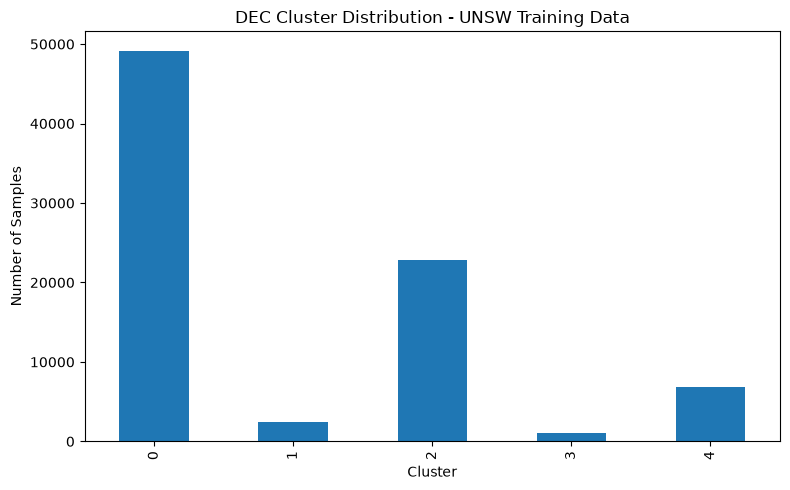

In [23]:
plt.figure(figsize=(8, 5))

cluster_counts.plot(kind="bar")

plt.xlabel("Cluster")
plt.ylabel("Number of Samples")
plt.title("DEC Cluster Distribution - UNSW Training Data")
plt.tight_layout()
plt.show()

In [40]:
METRIC_SAMPLE_SIZE = min(
    10000,
    len(X_train_df)
 )

metric_rng = np.random.RandomState(SEED)
metric_indices = metric_rng.choice(
    len(X_train_df),
    size=METRIC_SAMPLE_SIZE,
    replace=False
 )

X_train_metric = X_train_df.iloc[
    metric_indices
 ]
labels_train_metric = labels_train[metric_indices]

print("Metric sample size:", METRIC_SAMPLE_SIZE)
print(
    "Clusters in metric sample:",
    np.unique(labels_train_metric)
 )

if len(np.unique(labels_train_metric)) < 2:
    silhouette = np.nan
    db_score = np.nan
    ch_score = np.nan
    print("Metrics are undefined because fewer than 2 clusters are present.")
else:
    silhouette = silhouette_score(
        X_train_metric,
        labels_train_metric
    )
    
    db_score = davies_bouldin_score(
        X_train_metric,
        labels_train_metric
    )
    
    ch_score = calinski_harabasz_score(
        X_train_metric,
        labels_train_metric
    )

print("DEC Training Results")
print("--------------------")
print(f"Silhouette Score       : {silhouette:.4f}")
print(f"Davies-Bouldin Score   : {db_score:.4f}")
print(f"Calinski-Harabasz      : {ch_score:.4f}")
print(f"Training Time          : {training_time:.2f} sec")

Metric sample size: 10000
Clusters in metric sample: [0 1 2 3 4]
DEC Training Results
--------------------
Silhouette Score       : 0.2175
Davies-Bouldin Score   : 1.8780
Calinski-Harabasz      : 1221.1909
Training Time          : 45.25 sec


In [26]:
confidence = np.max(
    q_train,
    axis=1
)

entropy = -np.sum(
    q_train * np.log(q_train + 1e-10),
    axis=1
)

print(
    "Mean confidence:",
    confidence.mean()
)

print(
    "Mean entropy:",
    entropy.mean()
)

Mean confidence: 0.92487574
Mean entropy: 0.23132713


In [41]:
ARTIFACT_DIR = "dec_artifacts"

os.makedirs(
    ARTIFACT_DIR,
    exist_ok=True
)

dec_model.save_weights(
    f"{ARTIFACT_DIR}/dec_model.weights.h5"
)

encoder.save_weights(
    f"{ARTIFACT_DIR}/encoder.weights.h5"
)

autoencoder.save_weights(
    f"{ARTIFACT_DIR}/autoencoder.weights.h5"
)

In [42]:
joblib.dump(
    proto_encoder,
    f"{ARTIFACT_DIR}/proto_encoder.pkl"
)

joblib.dump(
    service_encoder,
    f"{ARTIFACT_DIR}/service_encoder.pkl"
)

joblib.dump(
    scaler,
    f"{ARTIFACT_DIR}/scaler.pkl"
)

joblib.dump(
    train_medians,
    f"{ARTIFACT_DIR}/train_medians.pkl"
)

['dec_artifacts/train_medians.pkl']

In [43]:
joblib.dump(
    selected_features,
    f"{ARTIFACT_DIR}/selected_features.pkl"
)

['dec_artifacts/selected_features.pkl']

In [44]:
metadata = {
    "latent_dim": 2,
    "n_clusters": 5,
    "input_dim": 24,
    "learning_rate": 0.001,
    "ae_epochs": 20,
    "dec_max_iterations": 500,
    "update_interval": 50,
    "seed": SEED
}

joblib.dump(
    metadata,
    f"{ARTIFACT_DIR}/metadata.pkl"
)

print("All DEC artifacts saved.")

All DEC artifacts saved.


In [45]:
UNSW_TEST_PATH = r"C:\AMRITA\Final_Year_Project_zero_day_27\model_selection_zeroday_fyp_27\UNSW_NB15_testing-set.csv"

test_df = pd.read_csv(
    UNSW_TEST_PATH
)

print("Test shape:", test_df.shape)

Test shape: (175341, 45)


In [47]:
def transform_with_unknown(series, encoder):
    mapping = {
        value: index
        for index, value in enumerate(encoder.classes_)
    }
    return series.astype(str).map(mapping).fillna(-1).astype(int)

X_test_df = test_df[selected_features].copy()

X_test_df["proto"] = transform_with_unknown(
    X_test_df["proto"],
    proto_encoder
 )
X_test_df["service"] = transform_with_unknown(
    X_test_df["service"],
    service_encoder
 )

X_test_df.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

X_test_df = X_test_df.fillna(
    train_medians
 )

X_test = scaler.transform(
    X_test_df
 )

print("Unknown test proto values:", (X_test_df["proto"] == -1).sum())
print("Test matrix:", X_test.shape)

q_test = dec_model.predict(
    X_test,
    batch_size=256,
    verbose=0
 )

labels_test = q_test.argmax(axis=1)

print(
    "Predicted clusters:",
    np.unique(labels_test)
 )

Unknown test proto values: 16
Test matrix: (175341, 24)
Predicted clusters: [0 1 2 3 4]


In [49]:
test_silhouette = silhouette_score(
    X_test,
    labels_test,
    sample_size=10000,
    random_state=42
)

test_db = davies_bouldin_score(
    X_test,
    labels_test
)

test_ch = calinski_harabasz_score(
    X_test,
    labels_test
)

print("UNSW Held-Out Test")
print("------------------")
print(f"Silhouette        : {test_silhouette:.4f}")
print(f"Davies-Bouldin    : {test_db:.4f}")
print(f"Calinski-Harabasz : {test_ch:.2f}")

UNSW Held-Out Test
------------------
Silhouette        : 0.2238
Davies-Bouldin    : 1.8441
Calinski-Harabasz : 21209.36


In [50]:
if "label" in test_df.columns:

    ari = adjusted_rand_score(
        test_df["label"],
        labels_test
    )

    nmi = normalized_mutual_info_score(
        test_df["label"],
        labels_test
    )

    print(f"ARI : {ari:.4f}")
    print(f"NMI : {nmi:.4f}")

ARI : 0.0923
NMI : 0.1245


In [72]:
COWRIE_BEHAVIOR_PATH = r"C:\AMRITA\Final_Year_Project_zero_day_27\model_selection_zeroday_fyp_27\behavior_features.csv"

cowrie_df = pd.read_csv(COWRIE_BEHAVIOR_PATH)

print("Shape:", cowrie_df.shape)
print(cowrie_df["proto"].value_counts())
print(cowrie_df["service"].value_counts())

Shape: (1800, 29)
proto
ssh    1800
Name: count, dtype: int64
service
ssh    1800
Name: count, dtype: int64


In [75]:
print("UNSW protocol classes:")
print(proto_encoder.classes_)

print("\nUNSW service classes:")
print(service_encoder.classes_)

UNSW protocol classes:
['3pc' 'a/n' 'aes-sp3-d' 'any' 'argus' 'aris' 'arp' 'ax.25' 'bbn-rcc'
 'bna' 'br-sat-mon' 'cbt' 'cftp' 'chaos' 'compaq-peer' 'cphb' 'cpnx'
 'crtp' 'crudp' 'dcn' 'ddp' 'ddx' 'dgp' 'egp' 'eigrp' 'emcon' 'encap'
 'etherip' 'fc' 'fire' 'ggp' 'gmtp' 'gre' 'hmp' 'i-nlsp' 'iatp' 'ib'
 'idpr' 'idpr-cmtp' 'idrp' 'ifmp' 'igmp' 'igp' 'il' 'ip' 'ipcomp' 'ipcv'
 'ipip' 'iplt' 'ipnip' 'ippc' 'ipv6' 'ipv6-frag' 'ipv6-no' 'ipv6-opts'
 'ipv6-route' 'ipx-n-ip' 'irtp' 'isis' 'iso-ip' 'iso-tp4' 'kryptolan'
 'l2tp' 'larp' 'leaf-1' 'leaf-2' 'merit-inp' 'mfe-nsp' 'mhrp' 'micp'
 'mobile' 'mtp' 'mux' 'narp' 'netblt' 'nsfnet-igp' 'nvp' 'ospf' 'pgm'
 'pim' 'pipe' 'pnni' 'pri-enc' 'prm' 'ptp' 'pup' 'pvp' 'qnx' 'rdp' 'rsvp'
 'rvd' 'sat-expak' 'sat-mon' 'sccopmce' 'scps' 'sctp' 'sdrp' 'secure-vmtp'
 'sep' 'skip' 'sm' 'smp' 'snp' 'sprite-rpc' 'sps' 'srp' 'st2' 'stp'
 'sun-nd' 'swipe' 'tcf' 'tcp' 'tlsp' 'tp++' 'trunk-1' 'trunk-2' 'ttp'
 'udp' 'unas' 'uti' 'vines' 'visa' 'vmtp' 'vrrp' 'wb-expak'

In [76]:
X_cowrie_df = cowrie_df[selected_features].copy()

# Cowrie SSH sessions run over TCP.
# UNSW-NB15 represents the transport protocol as "tcp"
# and the application service separately as "ssh".
X_cowrie_df["proto"] = (
    X_cowrie_df["proto"]
    .astype(str)
    .str.lower()
    .replace({"ssh": "tcp"})
)

X_cowrie_df["service"] = (
    X_cowrie_df["service"]
    .astype(str)
    .str.lower()
)

print("Cowrie protocol after mapping:")
print(X_cowrie_df["proto"].value_counts())

print("\nCowrie service:")
print(X_cowrie_df["service"].value_counts())

Cowrie protocol after mapping:
proto
tcp    1800
Name: count, dtype: int64

Cowrie service:
service
ssh    1800
Name: count, dtype: int64


In [97]:
cowrie_features = [
    "dur",
    "spkts",
    "dpkts",
    "sbytes",
    "dbytes",
    "rate",
    "sload",
    "dload",
    "sinpkt",
    "dinpkt",
    "sjit",
    "djit",
    "tcprtt",
    "synack",
    "ackdat",
    "ct_srv_src",
    "ct_src_ltm"
]

In [98]:
X_cowrie_df = cowrie_df[cowrie_features].copy()

In [99]:
X_cowrie_df.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

X_cowrie_df = X_cowrie_df.fillna(
    X_cowrie_df.median()
)

cowrie_scaler = StandardScaler()

X_cowrie_train = cowrie_scaler.fit_transform(
    X_cowrie_df
)

print(X_cowrie_train.shape)

(1800, 17)


In [100]:
X_cowrie_df.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

missing_before = X_cowrie_df.isna().sum().sum()

print(
    "Missing values before imputation:",
    missing_before
)

# Use Cowrie training medians
cowrie_medians = X_cowrie_df.median()

X_cowrie_df = X_cowrie_df.fillna(
    cowrie_medians
)

print(
    "Missing values after imputation:",
    X_cowrie_df.isna().sum().sum()
)

Missing values before imputation: 0
Missing values after imputation: 0


In [101]:
cowrie_scaler = StandardScaler()

X_cowrie = cowrie_scaler.fit_transform(
    X_cowrie_df
)

print(
    "Final input shape:",
    X_cowrie.shape
)

print(
    "Mean:",
    np.mean(X_cowrie, axis=0)[:5]
)

print(
    "Std:",
    np.std(X_cowrie, axis=0)[:5]
)

Final input shape: (1800, 17)
Mean: [ 7.10542736e-17  4.14483263e-17 -2.58558607e-16 -5.42775701e-17
 -1.18423789e-17]
Std: [1. 1. 1. 1. 1.]


In [102]:
input_dim = len(cowrie_features)
latent_dim = 2

inputs = Input(
    shape=(input_dim,),
    name="input"
)

x = Dense(32, activation="relu")(inputs)
x = Dense(16, activation="relu")(x)

latent = Dense(
    latent_dim,
    activation="linear",
    name="latent"
)(x)

x = Dense(16, activation="relu")(latent)
x = Dense(32, activation="relu")(x)

outputs = Dense(
    input_dim,
    activation="linear",
    name="reconstruction"
)(x)

cowrie_autoencoder = Model(
    inputs,
    outputs,
    name="Cowrie_Autoencoder"
)

cowrie_encoder = Model(
    inputs,
    latent,
    name="Cowrie_Encoder"
)

cowrie_autoencoder.summary()

Model: "Cowrie_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 17)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 2)              │            34 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 17)             │           561 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,291 (8.95 KB)

 Trainable params: 2,291 (8.95 KB)

 Non-trainable params: 0 (0.00 B)

In [103]:
cowrie_autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

start_time = time.time()

ae_history = cowrie_autoencoder.fit(
    X_cowrie,
    X_cowrie,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

ae_training_time = time.time() - start_time

print(
    f"AE training time: {ae_training_time:.2f} seconds"
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - loss: 1.0082 - val_loss: 0.8550
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.9786 - val_loss: 0.8331
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.9489 - val_loss: 0.8068
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.9109 - val_loss: 0.7731
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.8636 - val_loss: 0.7344
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.8129 - val_loss: 0.6957
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.7627 - val_loss: 0.6543
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.7096 - val_loss: 0.6097
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.6548 - val_loss: 0.5642
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.5999 - val_loss: 0.5178
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.5481 - val_loss: 0.4775
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.5043 - val_loss: 0.4460


In [104]:
latent_cowrie = cowrie_encoder.predict(
    X_cowrie,
    batch_size=256,
    verbose=0
)

print("Latent shape:", latent_cowrie.shape)

Latent shape: (1800, 2)


In [105]:
# ==========================================
# K-MEANS INITIALIZATION FOR DEC
# ==========================================

n_clusters = 5

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=SEED,
    n_init=20
)

initial_labels = kmeans.fit_predict(latent_cowrie)
initial_centers = kmeans.cluster_centers_

print("Initial cluster distribution:")
print(pd.Series(initial_labels).value_counts().sort_index())

print("\nInitial cluster centers:")
print(initial_centers)

Initial cluster distribution:
0    481
1     59
2    936
3    216
4    108
Name: count, dtype: int64

Initial cluster centers:
[[ 2.28437376e+00 -2.15185285e+00]
 [ 1.44421844e+01 -1.52388811e+00]
 [-4.31846619e-01 -1.10064745e-02]
 [ 5.92956066e+00 -5.24607468e+00]
 [ 9.17154884e+00 -8.16240311e-01]]


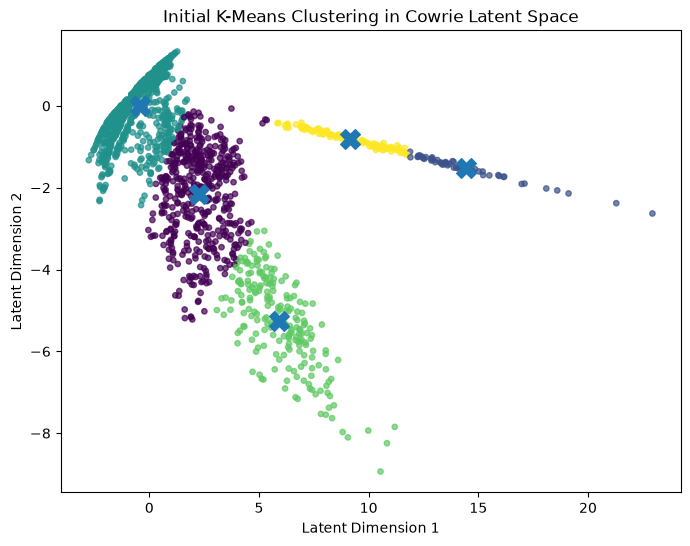

In [106]:
plt.figure(figsize=(8, 6))

plt.scatter(
    latent_cowrie[:, 0],
    latent_cowrie[:, 1],
    c=initial_labels,
    s=15,
    alpha=0.7
)

plt.scatter(
    initial_centers[:, 0],
    initial_centers[:, 1],
    marker="X",
    s=200
)

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("Initial K-Means Clustering in Cowrie Latent Space")
plt.show()

In [107]:
# ==========================================
# DEC CLUSTERING LAYER
# ==========================================

class ClusteringLayer(Layer):

    def __init__(self, n_clusters, alpha=1.0, **kwargs):
        super().__init__(**kwargs)
        self.n_clusters = n_clusters
        self.alpha = alpha

    def build(self, input_shape):
        input_dim = int(input_shape[-1])

        self.clusters = self.add_weight(
            shape=(self.n_clusters, input_dim),
            initializer="glorot_uniform",
            trainable=True,
            name="cluster_centers"
        )

        super().build(input_shape)

    def call(self, inputs):

        squared_distance = tf.reduce_sum(
            tf.square(
                tf.expand_dims(inputs, axis=1)
                - self.clusters
            ),
            axis=2
        )

        q = 1.0 / (
            1.0 + squared_distance / self.alpha
        )

        q = tf.pow(
            q,
            (self.alpha + 1.0) / 2.0
        )

        q = q / tf.reduce_sum(
            q,
            axis=1,
            keepdims=True
        )

        return q

In [108]:
# ==========================================
# BUILD COWRIE DEC
# ==========================================

clustering_layer = ClusteringLayer(
    n_clusters=n_clusters,
    name="clustering"
)

cluster_output = clustering_layer(
    cowrie_encoder.output
)

cowrie_dec = Model(
    cowrie_encoder.input,
    cluster_output,
    name="Cowrie_DEC"
)

# Initialize DEC cluster centers
# using the K-Means centers
clustering_layer.set_weights(
    [initial_centers]
)

cowrie_dec.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="kld"
)

cowrie_dec.summary()

Model: "Cowrie_DEC"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 17)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 2)              │            34 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clustering (ClusteringLayer)    │ (None, 5)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,148 (4.48 KB)

 Trainable params: 1,148 (4.48 KB)

 Non-trainable params: 0 (0.00 B)

In [109]:
q_initial = cowrie_dec.predict(
    X_cowrie,
    batch_size=256,
    verbose=0
)

print("q shape:", q_initial.shape)

print("\nFirst 5 soft assignments:")
print(q_initial[:5])

print("\nMean assignment probability:")
print(q_initial.mean(axis=0))

print("\nInitial confidence:")
print(q_initial.max(axis=1).mean())

q shape: (1800, 5)

First 5 soft assignments:
[[0.23378347 0.02542846 0.05641054 0.59654033 0.08783724]
 [0.01973602 0.04742876 0.01089024 0.03312443 0.8888206 ]
 [0.11745767 0.13172965 0.06173862 0.51056194 0.17851204]
 [0.19664223 0.01315341 0.7173442  0.03856233 0.03429781]
 [0.12943241 0.02032545 0.03605782 0.74601024 0.06817406]]

Mean assignment probability:
[0.27745938 0.0450089  0.46499142 0.13376604 0.07877387]

Initial confidence:
0.75226915


In [110]:
def target_distribution(q):

    weight = (
        q ** 2
    ) / (
        np.sum(q, axis=0) + 1e-10
    )

    return (
        weight /
        (
            np.sum(
                weight,
                axis=1,
                keepdims=True
            ) + 1e-10
        )
    )

In [111]:
p_initial = target_distribution(q_initial)

print("Target distribution shape:", p_initial.shape)

print("\nFirst 5 target distributions:")
print(p_initial[:5])

Target distribution shape: (1800, 5)

First 5 target distributions:
[[6.61803111e-02 4.82660951e-03 2.29919679e-03 8.93787742e-01
  3.29060555e-02]
 [1.39152122e-04 4.95399395e-03 2.52813425e-05 8.13057646e-04
  9.94068503e-01]
 [1.77792907e-02 1.37854129e-01 2.93102837e-03 6.96790278e-01
  1.44645169e-01]
 [1.09228104e-01 3.01271840e-03 8.67342293e-01 8.71286355e-03
  1.17039047e-02]
 [1.40683595e-02 2.13864585e-03 6.51494658e-04 9.69394326e-01
  1.37471585e-02]]


In [112]:
# ==========================================
# DEC TRAINING
# ==========================================

maxiter = 500
update_interval = 50
tol = 0.001

q = cowrie_dec.predict(
    X_cowrie,
    batch_size=256,
    verbose=0
)

p = target_distribution(q)

y_pred_last = q.argmax(axis=1)

training_iterations = 0

start_time = time.time()

for ite in range(maxiter):

    if ite % update_interval == 0:

        q = cowrie_dec.predict(
            X_cowrie,
            batch_size=256,
            verbose=0
        )

        p = target_distribution(q)

        y_pred = q.argmax(axis=1)

        if ite > 0:

            delta_label = np.sum(
                y_pred != y_pred_last
            ) / len(y_pred)

            print(
                f"Iteration {ite}: "
                f"label change = {delta_label:.6f}"
            )

            if delta_label < tol:

                print("DEC convergence reached.")

                training_iterations = ite

                break

        y_pred_last = y_pred.copy()

    loss = cowrie_dec.train_on_batch(
        X_cowrie,
        p
    )

    training_iterations = ite + 1

dec_training_time = time.time() - start_time

print("\nDEC training completed.")
print("Iterations:", training_iterations)
print(
    f"DEC training time: "
    f"{dec_training_time:.2f} seconds"
)

Iteration 50: label change = 0.028889
Iteration 100: label change = 0.022778
Iteration 150: label change = 0.015000
Iteration 200: label change = 0.012778
Iteration 250: label change = 0.007222
Iteration 300: label change = 0.005556
Iteration 350: label change = 0.003889
Iteration 400: label change = 0.002778
Iteration 450: label change = 0.003333

DEC training completed.
Iterations: 500
DEC training time: 8.52 seconds


In [113]:
# ==========================================
# FINAL DEC ASSIGNMENTS
# ==========================================

q_cowrie = cowrie_dec.predict(
    X_cowrie,
    batch_size=256,
    verbose=0
)

cowrie_labels = np.argmax(
    q_cowrie,
    axis=1
)

print("Final q shape:", q_cowrie.shape)

print("\nFinal cluster distribution:")
print(
    pd.Series(cowrie_labels)
    .value_counts()
    .sort_index()
)

print("\nFinal mean assignment probability:")
print(
    q_cowrie.mean(axis=0)
)

print("\nFinal mean confidence:")
print(
    q_cowrie.max(axis=1).mean()
)

Final q shape: (1800, 5)

Final cluster distribution:
0    497
1     80
2    845
3    288
4     90
Name: count, dtype: int64

Final mean assignment probability:
[0.27335563 0.04938537 0.45614138 0.16248739 0.05863013]

Final mean confidence:
0.89321023


In [114]:
# ==========================================
# FINAL COWRIE DEC INTERNAL METRICS
# ==========================================

sil = silhouette_score(
    X_cowrie,
    cowrie_labels
)

db = davies_bouldin_score(
    X_cowrie,
    cowrie_labels
)

ch = calinski_harabasz_score(
    X_cowrie,
    cowrie_labels
)

print("======================================")
print("COWRIE DEC RESULTS")
print("======================================")

print(f"Silhouette Score       : {sil:.4f}")
print(f"Davies-Bouldin Index   : {db:.4f}")
print(f"Calinski-Harabasz      : {ch:.4f}")
print(f"Training Time (sec)    : {dec_training_time:.2f}")
print(f"Iterations             : {training_iterations}")
print(f"Mean Confidence        : {q_cowrie.max(axis=1).mean():.4f}")

COWRIE DEC RESULTS
Silhouette Score       : 0.2836
Davies-Bouldin Index   : 1.5245
Calinski-Harabasz      : 548.9703
Training Time (sec)    : 8.52
Iterations             : 500
Mean Confidence        : 0.8932


In [117]:
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

if "label" not in cowrie_df.columns:
    raise KeyError(
        "Cowrie dataset must contain a 'label' column for ARI/NMI."
    )

binary_labels = cowrie_df["label"].astype(int).to_numpy()

if len(binary_labels) != len(cowrie_labels):
    raise ValueError(
        "Cowrie label count does not match predicted cluster count: "
        f"{len(binary_labels)} != {len(cowrie_labels)}"
    )

ari = adjusted_rand_score(
    binary_labels,
    cowrie_labels
 )

nmi = normalized_mutual_info_score(
    binary_labels,
    cowrie_labels
 )

print("\n======================================")
print("POST-HOC LABEL ALIGNMENT")
print("======================================")

print(f"ARI : {ari:.4f}")
print(f"NMI : {nmi:.4f}")


POST-HOC LABEL ALIGNMENT
ARI : 0.0935
NMI : 0.1395


In [119]:
# ==========================================
# CLUSTER × ATTACK CATEGORY
# ==========================================

cluster_attack = pd.crosstab(
    cowrie_df["attack_cat"],
    cowrie_labels,
    margins=True
)

print(cluster_attack)

col_0                                0   1    2    3   4   All
attack_cat                                                    
botnet_malware_download            147   0   87    0   0   234
brute_force_only                     0   0  222    0   0   222
evasion_anti_forensics             152   0   76    0   0   228
privilege_escalation                36   0   57  120   0   213
reconnaissance                      21   0   75  168   0   264
zero_day_buffer_overflow             0   0  217    0   0   217
zero_day_covert_tunnel             140   0   53    0   0   193
zero_day_obfuscated_memory_attack    1  80   58    0  90   229
All                                497  80  845  288  90  1800


In [120]:
cluster_attack_pct = pd.crosstab(
    cowrie_df["attack_cat"],
    cowrie_labels,
    normalize="index"
) * 100

print("\nRow-normalized percentages:")
print(cluster_attack_pct.round(2))


Row-normalized percentages:
col_0                                  0      1       2      3     4
attack_cat                                                          
botnet_malware_download            62.82   0.00   37.18   0.00   0.0
brute_force_only                    0.00   0.00  100.00   0.00   0.0
evasion_anti_forensics             66.67   0.00   33.33   0.00   0.0
privilege_escalation               16.90   0.00   26.76  56.34   0.0
reconnaissance                      7.95   0.00   28.41  63.64   0.0
zero_day_buffer_overflow            0.00   0.00  100.00   0.00   0.0
zero_day_covert_tunnel             72.54   0.00   27.46   0.00   0.0
zero_day_obfuscated_memory_attack   0.44  34.93   25.33   0.00  39.3
